# Phase 4: Training Strategy
**3-stage progressive fine-tuning** with checkpoint/resume, mixed-precision training, and per-epoch melanoma sensitivity tracking.

> ⚠️ **GPU memory note:** RTX 2000 Ada has 4GB VRAM. This notebook uses **Automatic Mixed Precision (AMP)** to fit EfficientNet-B4. If you hit `CUDA out of memory`, reduce `BATCH_SIZE` to 16 in Cell 1 and re-run.

In [ ]:
import json, logging, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_auc_score, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BASE_DIR    = Path(r'c:\graduation project')
DATA_DIR    = BASE_DIR / 'data'
MODELS_DIR  = BASE_DIR / 'models' / 'checkpoints'
METRICS_DIR = BASE_DIR / 'results' / 'metrics'
FIGURES_DIR = BASE_DIR / 'results' / 'figures'

logging.basicConfig(level=logging.INFO, format='%(asctime)s  %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('phase4')

with open(DATA_DIR / 'preprocessing_config.json') as f:
    cfg = json.load(f)

CLASSES      = cfg['classes']
NUM_CLASSES  = cfg['num_classes']
NORM_MEAN    = cfg['norm_mean']
NORM_STD     = cfg['norm_std']
IMG_SIZE     = cfg['img_size']
BATCH_SIZE   = cfg['batch_size']     # reduce to 16 if CUDA OOM
weights_arr  = [cfg['class_weights'][str(i)] for i in range(NUM_CLASSES)]
CLASS_WEIGHTS = torch.tensor(weights_arr, dtype=torch.float32).to(DEVICE)
MALIGNANT_CLASSES = ['melanoma', 'basal cell carcinoma', 'squamous cell carcinoma']

# v2 preprocessing (Phase 2 appendix): lesion segmentation + tight crop +
# background suppression, written to data/preprocessed_v2/. Read from
# preprocessing_config.json so Phase 4 and Phase 5 stay in sync.
USE_PREPROCESSED_V2 = cfg.get('use_v2', False)
PREPROCESSED_DIRS   = cfg.get('preprocessed_dirs', {'v1': 'preprocessed', 'v2': 'preprocessed_v2'})

print(f"Device     : {DEVICE}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Preprocessing : {'v2 (lesion-focused)' if USE_PREPROCESSED_V2 else 'v1'}")
print(f"AMP        : enabled" if DEVICE.type == 'cuda' else "AMP: disabled (CPU)")

## 1 · DataLoaders

In [ ]:
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = row.get('preprocessed_path') or row['image_path']
        if USE_PREPROCESSED_V2:
            v1_dir, v2_dir = PREPROCESSED_DIRS['v1'], PREPROCESSED_DIRS['v2']
            path = path.replace(f'\\{v1_dir}\\', f'\\{v2_dir}\\').replace(f'/{v1_dir}/', f'/{v2_dir}/')
        image = Image.open(path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, int(row['label_int'])


# v1 augmentation (rotation +/-15, inward zoom 0.90-1.0, brightness/contrast +/-10%)
train_transform_v1 = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=15),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.90, 1.0)),
    T.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.05, hue=0.02),
    T.ToTensor(),
    T.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

# v2 augmentation (Phase 2 appendix): wider rotation (+/-20), true zoom
# in/out (0.8x-1.2x via affine), brightness/contrast +/-10%, plus
# "multi-crop" -- each sample randomly gets either the full lesion view
# or a tighter zoomed-in crop of the lesion (RandomResizedCrop 0.5-0.9).
multi_crop_v2 = T.RandomChoice([
    T.Resize((IMG_SIZE, IMG_SIZE)),                                     # full lesion view
    T.RandomResizedCrop(IMG_SIZE, scale=(0.5, 0.9), ratio=(0.9, 1.1)),  # zoomed lesion crop
])
train_transform_v2 = T.Compose([
    multi_crop_v2,
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=20),
    T.RandomAffine(degrees=0, scale=(0.8, 1.2)),
    T.ColorJitter(brightness=0.10, contrast=0.10),
    T.ToTensor(),
    T.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

val_transform_v1 = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=NORM_MEAN, std=NORM_STD),
])
val_transform_v2 = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

train_transform = train_transform_v2 if USE_PREPROCESSED_V2 else train_transform_v1
val_transform   = val_transform_v2   if USE_PREPROCESSED_V2 else val_transform_v1

train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df   = pd.read_csv(DATA_DIR / 'val.csv')

train_loader = DataLoader(SkinLesionDataset(train_df, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(SkinLesionDataset(val_df,   val_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

log.info(f"Train: {len(train_df):,} ({len(train_loader)} batches)  |  Val: {len(val_df):,} ({len(val_loader)} batches)")

## 2 · Model

In [ ]:
class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation block (Hu et al., 2018).
    Learns per-channel attention weights from global context so the model
    can emphasise the feature channels most relevant to a given lesion
    (color/texture/border cues) before pooling into the classifier.
    """
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y


class SkinCancerModel(nn.Module):
    IN_FEATURES = 1792

    def __init__(self, num_classes: int = 8):
        super().__init__()
        base = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        self.features = base.features
        self.se       = SEBlock(self.IN_FEATURES, reduction=16)
        self.avgpool  = base.avgpool
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(self.IN_FEATURES),
            nn.Linear(self.IN_FEATURES, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes),
        )
        self.set_stage(1)

    def set_stage(self, stage: int):
        for p in self.features.parameters():
            p.requires_grad = False
        if stage == 2:
            for block in list(self.features.children())[5:]:
                for p in block.parameters():
                    p.requires_grad = True
        elif stage == 3:
            for p in self.features.parameters():
                p.requires_grad = True
        for p in self.se.parameters():
            p.requires_grad = True
        for p in self.classifier.parameters():
            p.requires_grad = True

    def forward(self, x):
        x = self.features(x)
        x = self.se(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


class FocalLoss(nn.Module):
    """
    Multi-class focal loss (Lin et al., 2017).
    Down-weights easy/well-classified examples via (1 - p_t)^gamma so the
    model spends more learning capacity on hard/rare cases, while `alpha`
    (CLASS_WEIGHTS) provides additional per-class balancing. Pairs with the
    sqrt-smoothed CLASS_WEIGHTS to avoid the over-correction seen with raw
    'balanced' weights + plain CrossEntropyLoss (21% test accuracy collapse).
    """
    def __init__(self, alpha=None, gamma: float = 2.0, label_smoothing: float = 0.1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha,
                              label_smoothing=self.label_smoothing, reduction='none')
        pt = torch.exp(-ce)
        focal = (1 - pt) ** self.gamma * ce
        return focal.mean()


model = SkinCancerModel(num_classes=NUM_CLASSES).to(DEVICE)

# Older checkpoints (Phase 3 model_init.pth, prior best_model_stage*.pth) were
# saved before the SE block existed, so they are missing `se.*` keys.
# strict=False loads everything that matches and leaves the new SE block at
# its random init -- it gets trained from scratch alongside the rest.
init_path = MODELS_DIR / 'model_init.pth'
if init_path.exists():
    missing, unexpected = model.load_state_dict(
        torch.load(init_path, map_location=DEVICE, weights_only=True), strict=False)
    log.info(f"Loaded initial weights from Phase 3 (missing={missing}, unexpected={unexpected})")

criterion = FocalLoss(alpha=CLASS_WEIGHTS, gamma=2.0, label_smoothing=0.1)

STAGE_CFG = {
    1: {'epochs': 10, 'lr': 1e-3, 'desc': 'Head only'},
    2: {'epochs': 20, 'lr': 1e-4, 'desc': 'Head + last 4 backbone blocks'},
    3: {'epochs': 10, 'lr': 1e-5, 'desc': 'Full model'},
}
EARLY_STOP_PATIENCE = 8

print("Model loaded \u2713")


## 3 · Medical Metrics

In [4]:
def compute_medical_metrics(y_true: np.ndarray, y_proba: np.ndarray) -> dict:
    """
    Compute macro AUC, and per-class sensitivity/specificity (one-vs-rest).
    Sensitivity = recall for that class (TP / (TP+FN))
    Specificity = true negative rate (TN / (TN+FP))
    """
    y_pred = y_proba.argmax(axis=1)

    try:
        auc_macro = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    except ValueError:
        auc_macro = float('nan')

    cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASSES)))
    sens, spec = {}, {}
    for i, cls in enumerate(CLASSES):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sens[cls] = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
        spec[cls] = tn / (tn + fp) if (tn + fp) > 0 else float('nan')

    return {'auc_macro': auc_macro, 'sensitivity': sens, 'specificity': spec, 'confusion_matrix': cm}


print("compute_medical_metrics defined ✓")

compute_medical_metrics defined ✓


## 4 · Train / Eval Epoch Functions (AMP-enabled)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    use_amp = device.type == 'cuda'

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=device.type, enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels, all_probs = [], []
    use_amp = device.type == 'cuda'

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        with autocast(device_type=device.type, enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        all_probs.append(torch.softmax(outputs.float(), dim=1).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    val_loss = running_loss / len(loader.dataset)
    y_true  = np.concatenate(all_labels)
    y_proba = np.concatenate(all_probs)
    metrics = compute_medical_metrics(y_true, y_proba)
    metrics['loss'] = val_loss
    return metrics


print("train_one_epoch / evaluate defined ✓")

## 5 · Optimiser / Scheduler Builders

In [ ]:
def build_optimizer(model, stage):
    base_lr = STAGE_CFG[stage]['lr']
    if stage == 1:
        return torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=base_lr, weight_decay=1e-4
        )
    head_params     = list(model.classifier.parameters()) + list(model.se.parameters())
    backbone_params = [p for p in model.features.parameters() if p.requires_grad]
    return torch.optim.AdamW([
        {'params': head_params,     'lr': base_lr},
        {'params': backbone_params, 'lr': base_lr / 10},
    ], weight_decay=1e-4)


def build_scheduler(optimizer, epochs):
    """
    Linear warmup for the first ~10% of epochs, then cosine annealing with
    warm restarts. Restarting the LR cycle periodically helps the optimizer
    escape the loss plateaus seen with ReduceLROnPlateau in earlier runs.
    """
    warmup_epochs = max(1, epochs // 10)
    warmup = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.1, total_iters=warmup_epochs)
    cosine = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=max(2, (epochs - warmup_epochs) // 2), T_mult=1, eta_min=1e-7)
    return torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup, cosine], milestones=[warmup_epochs])


print("Optimiser/scheduler builders defined \u2713")


## 6 · Training Curves Plot

In [7]:
def plot_training_curves(history_df: pd.DataFrame, stage: int):
    best_idx = history_df['val_auc_macro'].idxmax()
    best_epoch = history_df.loc[best_idx, 'epoch']

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train', marker='o', ms=3)
    axes[0].plot(history_df['epoch'], history_df['val_loss'],   label='val',   marker='o', ms=3)
    axes[0].axvline(best_epoch, color='red', linestyle='--', alpha=0.6, label='best epoch')
    axes[0].set_title(f'Stage {stage} — Loss')
    axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history_df['epoch'], history_df['val_auc_macro'], color='#1D9E75', marker='o', ms=3)
    axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.6)
    axes[1].axhline(0.93, color='gray', linestyle=':', label='target 0.93')
    axes[1].set_title(f'Stage {stage} — Val Macro AUC')
    axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(history_df['epoch'], history_df['sens_melanoma'], color='#E24B4A', marker='o', ms=3, label='Melanoma')
    if 'sens_basal_cell_carcinoma' in history_df:
        axes[2].plot(history_df['epoch'], history_df['sens_basal_cell_carcinoma'], color='#D85A30', marker='o', ms=3, label='BCC')
    if 'sens_squamous_cell_carcinoma' in history_df:
        axes[2].plot(history_df['epoch'], history_df['sens_squamous_cell_carcinoma'], color='#854F0B', marker='o', ms=3, label='SCC')
    axes[2].axhline(0.85, color='gray', linestyle=':', label='target 0.85')
    axes[2].axvline(best_epoch, color='red', linestyle='--', alpha=0.6)
    axes[2].set_title(f'Stage {stage} — Malignant Sensitivity')
    axes[2].set_xlabel('Epoch'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

    plt.suptitle(f'Stage {stage} Training Curves', fontweight='bold')
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f'training_curves_stage{stage}.png', dpi=150, bbox_inches='tight')
    plt.show()


print("plot_training_curves defined ✓")

plot_training_curves defined ✓


## 7 · Stage Training Loop (checkpoint + resume)

In [ ]:
def train_stage(model, stage, train_loader, val_loader, criterion, device):
    epochs = STAGE_CFG[stage]['epochs']
    model.set_stage(stage)

    optimizer = build_optimizer(model, stage)
    scheduler = build_scheduler(optimizer, epochs)
    scaler    = GradScaler(device.type, enabled=(device.type == 'cuda'))

    checkpoint_path = MODELS_DIR / f'best_model_stage{stage}.pth'
    history_path    = METRICS_DIR / f'history_stage{stage}.csv'
    state_path      = MODELS_DIR / 'training_state.json'

    best_val_auc = -1.0
    start_epoch  = 0
    history      = []
    patience_ctr = 0

    # ── Resume logic ──────────────────────────────────────────────────────────
    if state_path.exists():
        state = json.loads(state_path.read_text())
        if state.get('stage') == stage:
            start_epoch  = state['last_epoch'] + 1
            best_val_auc = state['best_val_auc']
            if checkpoint_path.exists():
                model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
            if history_path.exists():
                history = pd.read_csv(history_path).to_dict('records')
            print(f"Resuming Stage {stage} from epoch {start_epoch}, best AUC = {best_val_auc:.4f}")

    if start_epoch >= epochs:
        print(f"Stage {stage} already complete ({start_epoch}/{epochs} epochs).")
        if checkpoint_path.exists():
            model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
        return pd.DataFrame(history), best_val_auc

    print(f"\n{'='*70}\n  STAGE {stage}: {STAGE_CFG[stage]['desc']}  "
          f"({epochs} epochs, lr={STAGE_CFG[stage]['lr']})\n{'='*70}")

    for epoch in range(start_epoch, epochs):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
        val_metrics = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        elapsed = time.time() - t0

        row = {
            'epoch'     : epoch,
            'train_loss': train_loss,
            'val_loss'  : val_metrics['loss'],
            'val_auc_macro': val_metrics['auc_macro'],
            'lr'        : optimizer.param_groups[0]['lr'],
            'time_sec'  : round(elapsed, 1),
        }
        for cls in MALIGNANT_CLASSES:
            key = cls.replace(' ', '_')
            row[f'sens_{key}'] = val_metrics['sensitivity'][cls]
            row[f'spec_{key}'] = val_metrics['specificity'][cls]

        history.append(row)
        pd.DataFrame(history).to_csv(history_path, index=False)

        print(f"  Epoch {epoch+1:>2}/{epochs} | loss={train_loss:.4f} "
              f"val_loss={val_metrics['loss']:.4f} val_auc={val_metrics['auc_macro']:.4f} "
              f"melanoma_sens={row['sens_melanoma']:.4f} | lr={row['lr']:.2e} | {elapsed:.0f}s")

        # Checkpoint best model (by val_auc)
        if val_metrics['auc_macro'] > best_val_auc:
            best_val_auc = val_metrics['auc_macro']
            torch.save(model.state_dict(), checkpoint_path)
            patience_ctr = 0
            print(f"    → new best (val_auc={best_val_auc:.4f}) — checkpoint saved")
        else:
            patience_ctr += 1

        state_path.write_text(json.dumps({
            'stage': stage, 'last_epoch': epoch, 'best_val_auc': best_val_auc
        }))

        if patience_ctr >= EARLY_STOP_PATIENCE:
            print(f"  Early stopping — no improvement for {EARLY_STOP_PATIENCE} epochs")
            break

    # Restore best weights for this stage
    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    history_df = pd.DataFrame(history)
    plot_training_curves(history_df, stage)
    return history_df, best_val_auc


print("train_stage defined ✓")

## 8 · Stage 1 — Train Head Only

C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2937693747.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=(device.type == 'cuda'))



  STAGE 1: Head only  (10 epochs, lr=0.001)


C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


  Epoch  1/10 | loss=1.1743 val_loss=1.1393 val_auc=0.7712 melanoma_sens=0.3305 | lr=1.00e-03 | 95s
    → new best (val_auc=0.7712) — checkpoint saved


C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


...

  Epoch  8/10 | loss=1.0820 val_loss=1.0792 val_auc=0.7970 melanoma_sens=0.3391 | lr=1.00e-03 | 28s


C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


  Epoch  9/10 | loss=1.0941 val_loss=1.0724 val_auc=0.8180 melanoma_sens=0.3863 | lr=3.00e-04 | 28s


C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


  Epoch 10/10 | loss=1.0585 val_loss=1.0567 val_auc=0.8291 melanoma_sens=0.3820 | lr=3.00e-04 | 28s
    → new best (val_auc=0.8291) — checkpoint saved


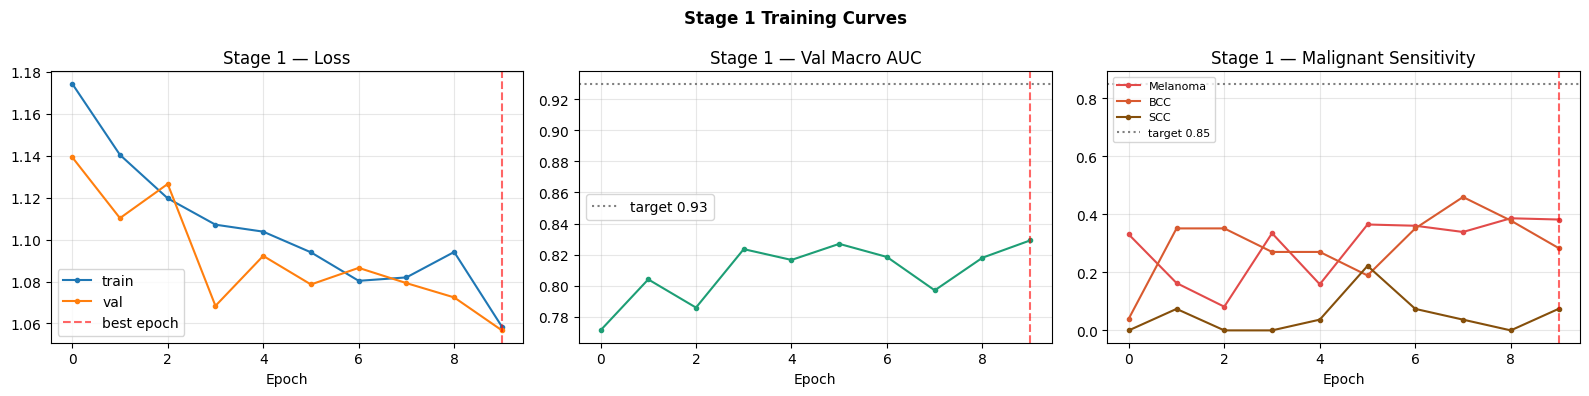


Stage 1 best val AUC: 0.8291


In [9]:
history_s1, best_auc_s1 = train_stage(model, 1, train_loader, val_loader, criterion, DEVICE)
print(f"\nStage 1 best val AUC: {best_auc_s1:.4f}")
torch.cuda.empty_cache()

## 9 · Stage 2 — Unfreeze Last 4 Backbone Blocks
Proceeds only if Stage 1 achieved val_auc > 0.80


  STAGE 2: Head + last 4 backbone blocks  (20 epochs, lr=0.0001)


C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2937693747.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=(device.type == 'cuda'))
C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


  Epoch  1/20 | loss=1.0513 val_loss=1.0506 val_auc=0.8197 melanoma_sens=0.3777 | lr=1.00e-04 | 37s
    → new best (val_auc=0.8197) — checkpoint saved


C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


  Epoch  2/20 | loss=1.0514 val_loss=1.0512 val_auc=0.8246 melanoma_sens=0.3648 | lr=1.00e-04 | 37s
    → new best (val_auc=0.8246) — checkpoint saved


...

  Epoch 18/20 | loss=0.9634 val_loss=0.9902 val_auc=0.8518 melanoma_sens=0.3433 | lr=1.00e-04 | 37s


C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


  Epoch 19/20 | loss=0.9543 val_loss=0.9904 val_auc=0.8467 melanoma_sens=0.3820 | lr=1.00e-04 | 37s


C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


  Epoch 20/20 | loss=0.9572 val_loss=0.9854 val_auc=0.8553 melanoma_sens=0.3433 | lr=1.00e-04 | 37s
    → new best (val_auc=0.8553) — checkpoint saved


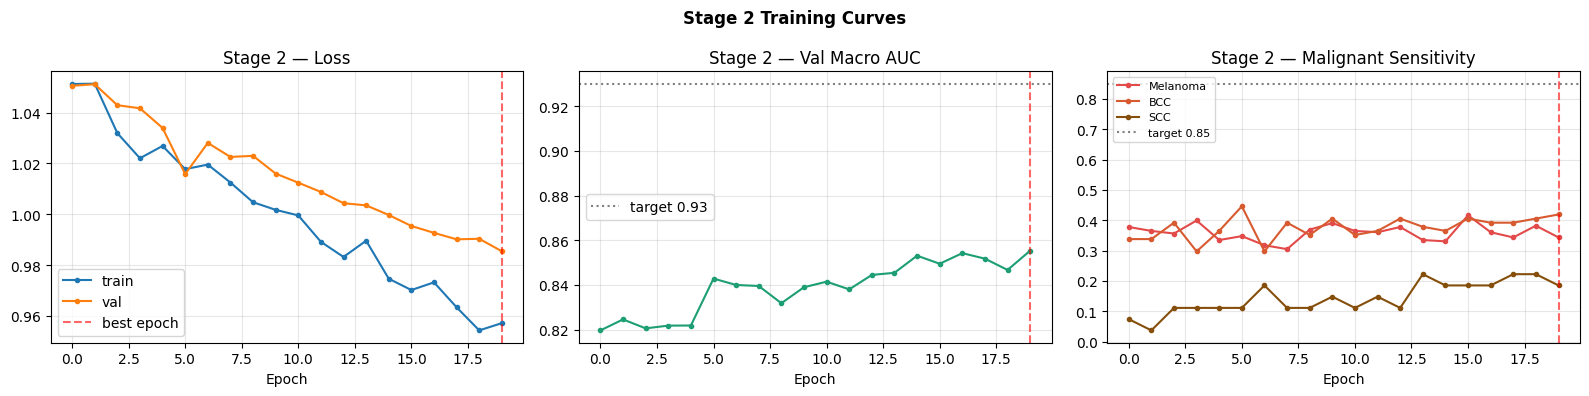


Stage 2 best val AUC: 0.8553


In [10]:
if best_auc_s1 > 0.75:
    history_s2, best_auc_s2 = train_stage(model, 2, train_loader, val_loader, criterion, DEVICE)
    print(f"\nStage 2 best val AUC: {best_auc_s2:.4f}")
else:
    print(f"Stage 1 val_auc ({best_auc_s1:.4f}) <= 0.75 — skipping Stage 2.")
    print("Consider: more epochs in Stage 1, or check data/preprocessing quality.")
    history_s2, best_auc_s2 = pd.DataFrame(), best_auc_s1

torch.cuda.empty_cache()

## 10 · Stage 3 — Full Fine-Tuning
Proceeds only if Stage 2 improved val_auc by > 1%


  STAGE 3: Full model  (10 epochs, lr=1e-05)


C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2937693747.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=(device.type == 'cuda'))
C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


  Epoch  1/10 | loss=0.9600 val_loss=0.9882 val_auc=0.8524 melanoma_sens=0.3348 | lr=1.00e-05 | 57s
    → new best (val_auc=0.8524) — checkpoint saved


C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


  Epoch  2/10 | loss=0.9480 val_loss=0.9822 val_auc=0.8574 melanoma_sens=0.3648 | lr=1.00e-05 | 57s
    → new best (val_auc=0.8574) — checkpoint saved


...

  Epoch  8/10 | loss=0.9561 val_loss=0.9836 val_auc=0.8552 melanoma_sens=0.3906 | lr=1.00e-05 | 57s


C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


  Epoch  9/10 | loss=0.9569 val_loss=0.9836 val_auc=0.8598 melanoma_sens=0.3433 | lr=1.00e-05 | 57s
    → new best (val_auc=0.8598) — checkpoint saved


C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
C:\Users\Admin\AppData\Local\Temp\ipykernel_27476\2831428304.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


  Epoch 10/10 | loss=0.9499 val_loss=0.9819 val_auc=0.8499 melanoma_sens=0.3820 | lr=1.00e-05 | 57s


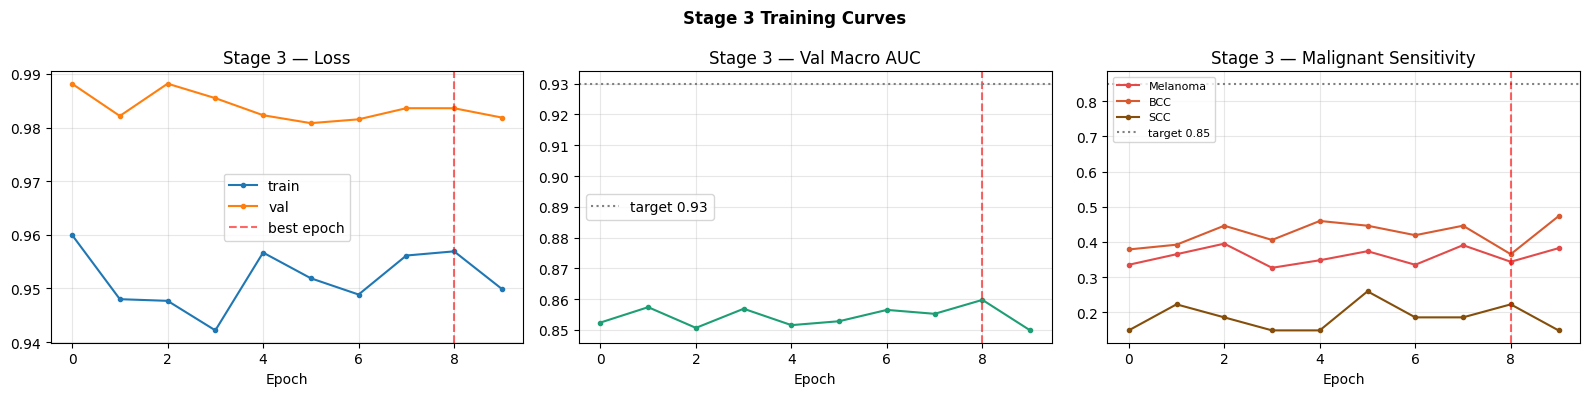


Stage 3 best val AUC: 0.8598


In [11]:
improvement = best_auc_s2 - best_auc_s1

if not history_s2.empty and improvement > 0.01:
    history_s3, best_auc_s3 = train_stage(model, 3, train_loader, val_loader, criterion, DEVICE)
    print(f"\nStage 3 best val AUC: {best_auc_s3:.4f}")
else:
    print(f"Stage 2→2 improvement ({improvement:.4f}) <= 0.01 — skipping Stage 3.")
    history_s3, best_auc_s3 = pd.DataFrame(), best_auc_s2

torch.cuda.empty_cache()

## 11 · Final Model

In [12]:
# Save the final best model (whichever stage achieved highest val_auc)
best_overall = max(
    [(best_auc_s1, 1), (best_auc_s2, 2), (best_auc_s3, 3)],
    key=lambda x: x[0]
)
best_auc, best_stage = best_overall
best_ckpt = MODELS_DIR / f'best_model_stage{best_stage}.pth'

model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE, weights_only=True))
final_path = MODELS_DIR / 'final_model.pth'
torch.save(model.state_dict(), final_path)

print("="*60)
print("  TRAINING COMPLETE")
print("="*60)
print(f"  Best stage    : {best_stage}")
print(f"  Best val AUC  : {best_auc:.4f}")
print(f"  Final model   : {final_path}")
print("="*60)

# Combined training summary
summary = pd.DataFrame([
    {'stage': 1, 'best_val_auc': best_auc_s1, 'epochs_run': len(history_s1)},
    {'stage': 2, 'best_val_auc': best_auc_s2, 'epochs_run': len(history_s2)},
    {'stage': 3, 'best_val_auc': best_auc_s3, 'epochs_run': len(history_s3)},
])
summary.to_csv(METRICS_DIR / 'training_summary.csv', index=False)
print(summary.to_string(index=False))

  TRAINING COMPLETE
  Best stage    : 3
  Best val AUC  : 0.8598
  Final model   : c:\graduation project\models\checkpoints\final_model.pth
 stage  best_val_auc  epochs_run
     1      0.829127          10
     2      0.855336          20
     3      0.859769          10


## Phase 4 Complete ✓

| Output | Path |
|--------|------|
| Best model per stage | `models/checkpoints/best_model_stage{1,2,3}.pth` |
| Final model | `models/checkpoints/final_model.pth` |
| Per-stage history | `results/metrics/history_stage{1,2,3}.csv` |
| Training curves | `results/figures/training_curves_stage{1,2,3}.png` |
| Training summary | `results/metrics/training_summary.csv` |

**Resuming:** if a Kaggle/local session is interrupted mid-stage, just re-run this notebook — `training_state.json` picks up from the last completed epoch.

**Next → Phase 5: Medical Evaluation** — confusion matrix, ROC/AUC, bootstrapped CI, SOTA comparison on the held-out test set